# Module 04 Lab - Exploratory Data Analysis**Objective:** To learn how to explore a dataset to find patterns, anomalies, and insights before modeling. EDA is like being a detective; you are looking for clues in the data that will help you build a better model.**This lab is fully coded.** Your task is to run each cell, read the detailed explanations, understand the purpose of each visualization, and then complete the experimentation section.

## Part 1: Setup and Data Loading**What is Exploratory Data Analysis (EDA)?**EDA is the process of using summary statistics and visualizations to understand a dataset's main characteristics. Before you can build a model, you need to understand your data. What stories does it tell? Are there errors or missing values? Are there strong relationships between variables? EDA helps answer these questions.We will use the famous Titanic dataset for this lab. It contains information about passengers and, crucially, whether they survived the disaster.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Basic Info ---")
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

## Part 2: Descriptive StatisticsLet's start by getting a high-level numerical summary of the data. The `.describe()` method is perfect for this. It calculates statistics like mean, standard deviation, min, and max for the numerical columns.

In [3]:
# Get summary statistics for numerical columns
print("--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Key Insights from Statistics ---")
print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")
print(f"The overall survival rate was {df['Survived'].mean():.1%}.")
print(f"Fares ranged from ${df['Fare'].min()} to a whopping ${df['Fare'].max()}.")

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

--- Key Insights from Statistics ---
The average 

## Part 3: Visual EDA - Telling Stories with PlotsNumbers are great, but plots make patterns and relationships immediately obvious. The goal of visual EDA is to turn data into insights.**A Note on Plotting Libraries:***   **Matplotlib:** The foundational library, gives you full control over everything.*   **Seaborn:** Built on Matplotlib, it provides a simpler, high-level interface for creating common statistical plots. We will use Seaborn for its ease of use and attractive defaults.

### Visualization 1: How many survived?A simple `countplot` is the best way to see the distribution of a categorical variable, like our target `Survived`.

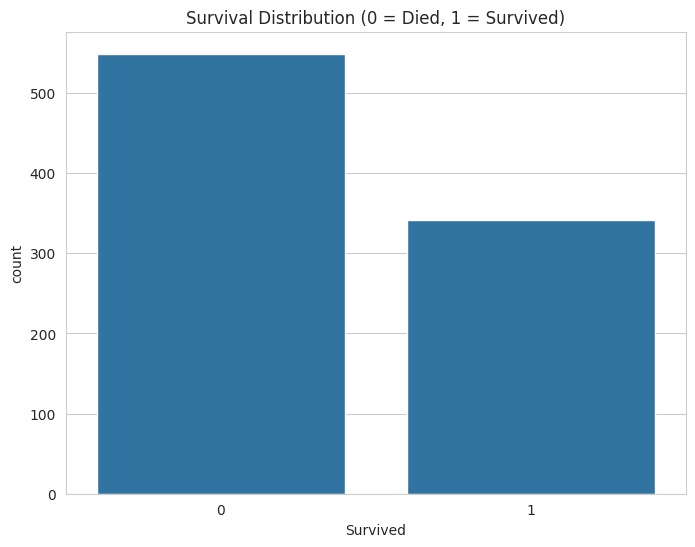

Insight: More passengers died than survived. This shows that the dataset is imbalanced.


In [4]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution (0 = Died, 1 = Survived)")
plt.show()

print(
    "Insight: More passengers died than survived. "
    "This shows that the dataset is imbalanced."
)

### Visualization 2: Does passenger class matter for survival?Now we want to see if there's a relationship between two variables. We can use the `hue` parameter in `countplot` to split the bars by another category.

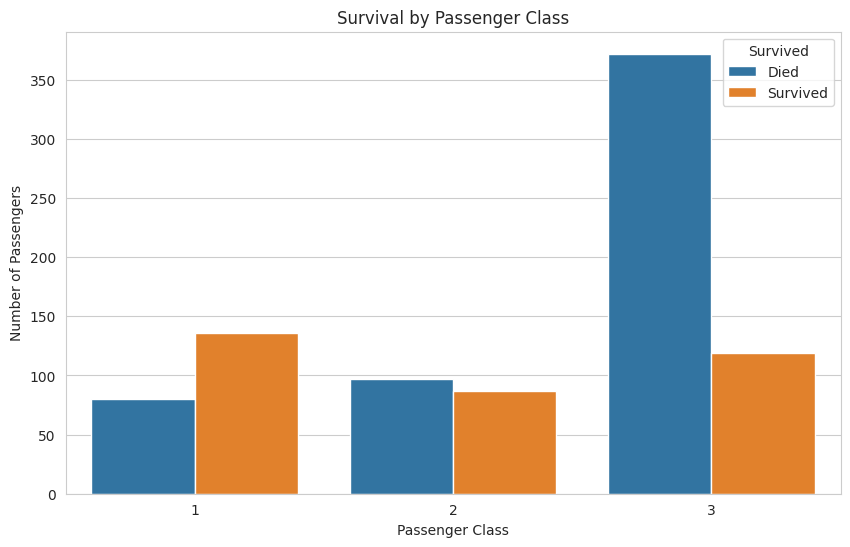

Insight: First-class passengers had a much higher chance of survival than third-class passengers. Passenger class was strongly related to survival.


In [5]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died", "Survived"])
plt.show()

print(
    "Insight: First-class passengers had a much higher chance of survival "
    "than third-class passengers. Passenger class was strongly related to survival."
)

### Visualization 3: What about gender?The 'women and children first' mantra is famous. Let's see if the data supports it.

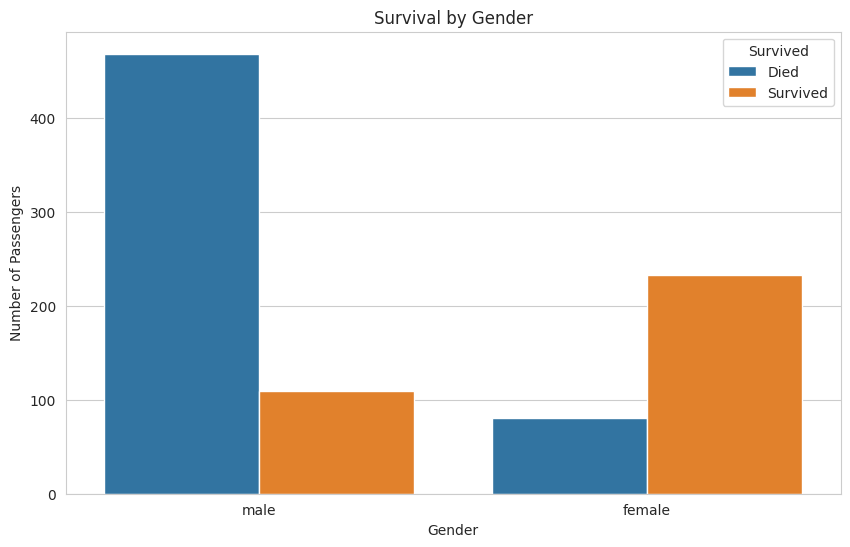

Insight: Female passengers had a much higher survival rate than male passengers. Gender was one of the strongest predictors of survival.


In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died", "Survived"])
plt.show()

print(
    "Insight: Female passengers had a much higher survival rate than male passengers. "
    "Gender was one of the strongest predictors of survival."
)

### Visualization 4: How does age play a role?For a continuous variable like `Age`, a histogram is a great way to see its distribution.

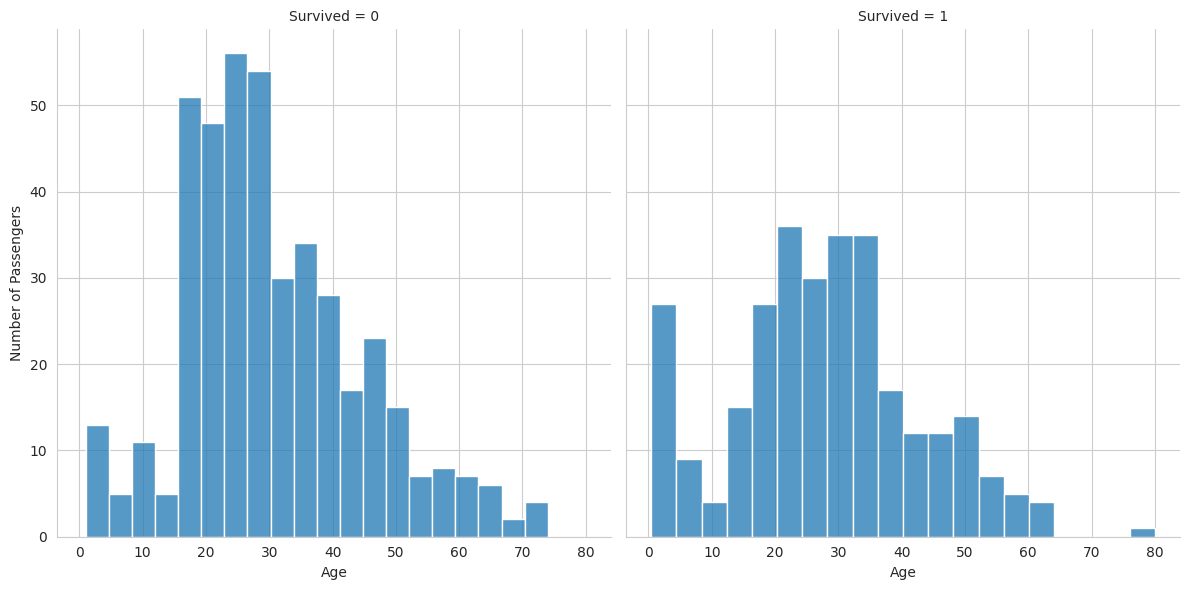

Insight: Many passengers who did not survive were between ages 20 and 40. The survivor plot also shows a noticeable group of young children, suggesting that children had a better chance of survival.


In [7]:
# Compare age distributions for passengers who died and survived
g = sns.FacetGrid(df, col="Survived", height=6)
g.map_dataframe(sns.histplot, x="Age", bins=20)

g.set_axis_labels("Age", "Number of Passengers")
g.set_titles("Survived = {col_name}")
plt.show()

print(
    "Insight: Many passengers who did not survive were between ages 20 and 40. "
    "The survivor plot also shows a noticeable group of young children, suggesting "
    "that children had a better chance of survival."
)

## Part 4: Student Experimentation**Instructions:** Create your own visualizations to explore other relationships in the data.

### Experiment 1: Port of Embarkation1.  The `Embarked` column tells you where a passenger boarded the ship (C = Cherbourg, Q = Queenstown, S = Southampton).2.  Create a `countplot` to see how survival rates differed by the port of embarkation. Does where they boarded seem to be related to their survival?

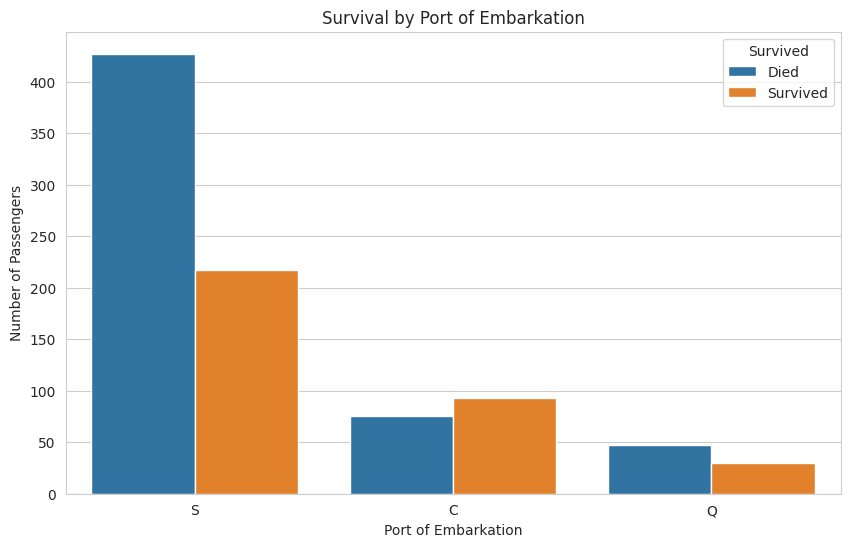

Insight: Passengers who boarded at Cherbourg had a higher proportion of survivors than passengers who boarded at Southampton or Queenstown. The port of embarkation appears to be related to survival.


In [8]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x="Embarked",
    hue="Survived",
    data=df
)

plt.title("Survival by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died", "Survived"])
plt.show()

print(
    "Insight: Passengers who boarded at Cherbourg had a higher proportion "
    "of survivors than passengers who boarded at Southampton or Queenstown. "
    "The port of embarkation appears to be related to survival."
)

### Experiment 2: Fare vs. Survival1.  `Fare` is a continuous numerical variable.2.  A `boxplot` or `violinplot` is a great way to see the distribution of fares for those who survived vs. those who didn't.3.  Create one of these plots to compare the `Fare` distribution by `Survived`. What does it tell you?

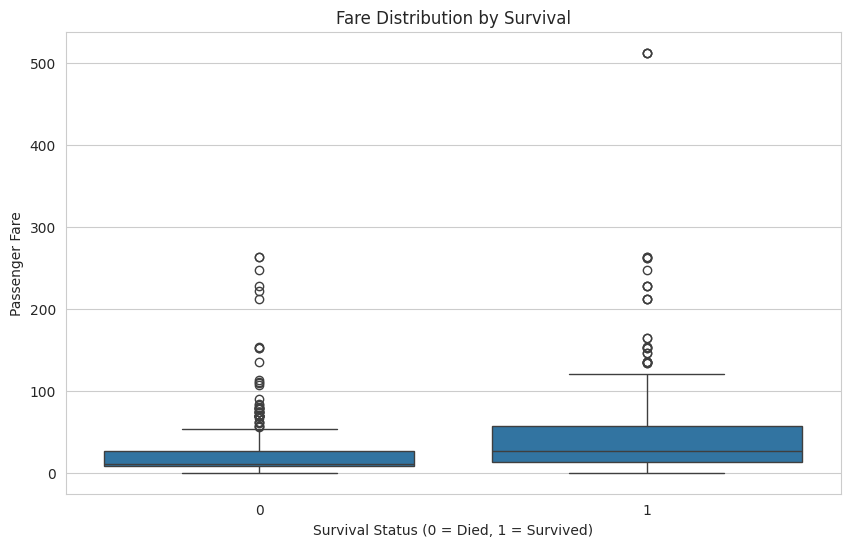

Insight: Passengers who survived generally paid higher fares than those who did not survive. This may be connected to higher-fare passengers being more likely to travel in first class.


In [9]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Survived",
    y="Fare",
    data=df
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survival Status (0 = Died, 1 = Survived)")
plt.ylabel("Passenger Fare")
plt.show()

print(
    "Insight: Passengers who survived generally paid higher fares than those "
    "who did not survive. This may be connected to higher-fare passengers "
    "being more likely to travel in first class."
)

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **What is the primary goal of Exploratory Data Analysis (EDA)?**2.  **Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?** (Describe them in terms of class, gender, and age).3.  **Why is it important to visualize data instead of just looking at summary statistics?** What can a plot show you that a number like 'mean' or 'count' can't?
1. The main purpose of Exploratory Data Analysis is to familiarize oneself with the data before training the model‚ and to identify relationships‚ features‚ missing values and outliers․

2. The models indicated that the young female first-class passenger was the passenger most likely to survive the Titanic disaster‚ and that women and children had higher survival than men‚ and first-class passengers had a higher survival than third-class․

3. Visualizations allow us to see patterns‚ differences‚ trends‚ and outliers more easily․ A mean or a count provides only one number‚ whereas a plot shows how the values are distributed and how different variables relate to (or influence) each other․